In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot
import pickle
import random, warnings, os
import datetime
import time 

In [2]:
warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Rulăm pe: {device}")

print(torch.cuda.get_device_name(0))

Rulăm pe: cuda
NVIDIA GeForce RTX 3080 Laptop GPU


In [3]:
CSV_PATH = "PEMS-BAY.csv"

# Construirea secvențelor de intrare folosind o fereastră temporală
def build_dataset(data, lookback=12):
    X, y = [], []
    for i in range(len(data)-lookback):
        X.append(data[i:i+lookback])
        y.append(data[i+lookback])
    return np.array(X), np.array(y)


In [4]:
print("Încarc date...")
df = pd.read_csv(CSV_PATH).dropna()

data = df.iloc[:,1:].values.astype(np.float32)
print("Date shape:", data.shape)


Încarc date...
Date shape: (52116, 325)


In [5]:
LOOKBACK = 12

X, y = build_dataset(data, LOOKBACK)

print(f"Input shape (X): {X.shape}")
print(f"Output shape (y): {y.shape}")

# Împărțirea datelor în seturi de antrenare, validare și testare
n_samples = len(X)
train_end = int(0.7*n_samples)
val_end   = int(0.85*n_samples)

X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
y_train, y_val, y_test = y[:train_end], y[train_end:val_end], y[val_end:]

print("Train/Val/Test:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

Input shape (X): (52104, 12, 325)
Output shape (y): (52104, 325)
Train/Val/Test: 36472 7816 7816


In [6]:
# Normalizarea datelor în intervalul [0,1]
scaler_X = MinMaxScaler()
X_train_s = scaler_X.fit_transform(X_train.reshape(-1, X_train.shape[2])).reshape(X_train.shape)
X_val_s = scaler_X.transform(X_val.reshape(-1, X_val.shape[2])).reshape(X_val.shape)
X_test_s = scaler_X.transform(X_test.reshape(-1, X_test.shape[2])).reshape(X_test.shape)

scaler_y = MinMaxScaler()
y_train_s = scaler_y.fit_transform(y_train)
y_val_s   = scaler_y.transform(y_val)
y_test_s  = scaler_y.transform(y_test)

# Conversia datelor în tensori PyTorch
X_train_t = torch.tensor(X_train_s, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32).to(device)
X_val_t   = torch.tensor(X_val_s, dtype=torch.float32).to(device)
y_val_t   = torch.tensor(y_val_s, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test_s, dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test_s, dtype=torch.float32).to(device)

In [7]:
# Definirea arhitecturii LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_units, output_dim, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_units,
            num_layers=2, 
            batch_first=True,
            dropout=dropout if dropout > 0 else 0
        )
        self.fc = nn.Linear(hidden_units, output_dim)

    def forward(self, x):  # Se utilizează ultima ieșire temporală pentru realizarea predicției
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

In [8]:
# Antrenarea modelului pentru evaluarea unei configurații candidate
def train_model(model, lr, batch_size, epochs=10):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        model.train()
        for xb, yb in loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5) # Limitarea normei gradientului pentru stabilizarea antrenării
            optimizer.step()
            
   # Evaluarea configurației pe setul de validare
    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_t)
        val_loss = criterion(val_pred, y_val_t)
    return val_loss.item()

In [9]:
def fitness_function(params):
# Conversia parametrilor optimizați în hiperparametrii modelului
    hidden_units = int(params[0])
    lr = 10**params[1]
    dropout = np.clip(10**params[2], 0.0, 0.4)
    batch_size = [16, 32, 64][np.argmin(np.abs(np.array([16, 32, 64]) - params[3]))]

    model = LSTMModel(X_train_s.shape[2], hidden_units, y_train_s.shape[1], dropout).to(device)
    mse_val = train_model(model, lr, batch_size, epochs=15)
    model.eval()
    with torch.no_grad():
        pred_val = model(X_val_t).cpu().numpy()

    std_real = np.std(y_val_s)
    std_pred = np.std(pred_val)
    variance_penalty = abs(std_real - std_pred)
    
    return mse_val + (0.5 * variance_penalty) 

In [10]:
class WOA_Hyper:
    def __init__(self, func, dim=4, population=10, max_iter=5): 
        self.func = func
        self.dim = dim
        self.population = population
        self.max_iter = max_iter
        self.lb = np.array([32, -4.5, -2.0, 16]) 
        self.ub = np.array([256, -2.0, -0.5, 64])  
        self.positions = np.random.uniform(self.lb, self.ub, (population, dim))
        self.fitness = np.array([func(p) for p in self.positions])
        best_idx = np.argmin(self.fitness)
        self.best_pos = self.positions[best_idx].copy()
        self.best_val = self.fitness[best_idx]
        self.history = []

    def optimize(self):
        for t in range(self.max_iter):
            a = 2 - 2 * (t / self.max_iter)

            for i in range(self.population):
                r1 = np.random.rand()
                r2 = np.random.rand()
                A = 2 * a * r1 - a
                C = 2 * r2
                p = np.random.rand()
                
                if p < 0.5:
                    if abs(A) < 1:
                        # Faza de exploatare
                        D = np.abs(C * self.best_pos - self.positions[i])
                        new_pos = self.best_pos - A * D
                    else:
                        # Faza de explorare
                        rand_idx = np.random.randint(self.population)
                        X_rand = self.positions[rand_idx]
                        D = np.abs(C * X_rand - self.positions[i])
                        new_pos = X_rand - A * D
                else:
                   # Actualizarea poziției folosind mișcarea spiralată
                    D = np.abs(self.best_pos - self.positions[i])
                    l = np.random.uniform(-1, 1) 
                    b = 1
                    new_pos = D * np.exp(b * l) * np.cos(2 * np.pi * l) + self.best_pos
                
               # Limitarea parametrilor la intervalele definite
                new_pos = np.clip(new_pos, self.lb, self.ub)
                
                fit = self.func(new_pos)
                
                if fit < self.fitness[i]:
                    self.positions[i] = new_pos
                    self.fitness[i] = fit
                
                if fit < self.best_val:
                    self.best_pos = new_pos.copy()
                    self.best_val = fit
                    
            self.history.append(self.best_val)
            print(f"Iter {t+1}/{self.max_iter} | Best Fitness: {self.best_val:.6f}")

        return self.best_pos, self.best_val, self.history

In [11]:
print("\nÎncep optimizarea WOA ...")
start = time.time()
woa = WOA_Hyper(fitness_function, population=10, max_iter=5) 
best_h, best_fit, history = woa.optimize()

print(f"Done WOA in {(time.time()-start)/60:.2f} minute")

# Conversia soluției optime în hiperparametrii modelului
hidden_units_opt = int(best_h[0])
lr_opt = 10**best_h[1]
dropout_opt = np.clip(10**best_h[2], 0.0, 0.4)

batch_options = [16, 32, 64]
batch_opt = batch_options[np.argmin(np.abs(np.array(batch_options) - best_h[3]))]

print("\n HIPERPARAMETRI OPTIMIZAȚI (WOA):")
print(f" Hidden units : {hidden_units_opt}")
print(f" Learning rate: {lr_opt:.6f}")
print(f" Dropout      : {dropout_opt:.6f}")
print(f" Batch size   : {batch_opt}")
print(f" Best Fitness (MSE+Var): {best_fit:.6f}")



Încep optimizarea WOA ...
Iter 1/5 | Best Fitness: 0.008092
Iter 2/5 | Best Fitness: 0.007436
Iter 3/5 | Best Fitness: 0.007436
Iter 4/5 | Best Fitness: 0.007436
Iter 5/5 | Best Fitness: 0.007436
Done WOA in 122.77 minute

 HIPERPARAMETRI OPTIMIZAȚI (WOA):
 Hidden units : 131
 Learning rate: 0.001048
 Dropout      : 0.010000
 Batch size   : 32
 Best Fitness (MSE+Var): 0.007436


In [12]:
# Parametrii utilizați pentru antrenarea finală
hidden_units_opt = int(best_h[0])
lr_opt = 10**best_h[1]
dropout_opt = np.clip(10**best_h[2], 0.0, 0.4) 
batch_options = [16, 32, 64]
batch_opt = batch_options[np.argmin(np.abs(np.array(batch_options) - best_h[3]))]

print(f"\n Antrenament Final: hidden={hidden_units_opt}, lr={lr_opt:.6f}, dropout={dropout_opt:.6f}, batch={batch_opt}")
start_train = time.time()

# Inițializarea modelului și a optimizatorului
model = LSTMModel(
    input_size=X_train_s.shape[2],
    hidden_units=hidden_units_opt,
    output_dim=y_train_s.shape[1],
    dropout=dropout_opt
).to(device)

criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=lr_opt)
dataset = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset, batch_size=batch_opt, shuffle=True)

num_epochs = 50 

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for xb, yb in loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)  # Limitarea gradientului pentru stabilizarea antrenării
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss /= len(loader)
    
    # Monitorizarea evoluției procesului de antrenare
    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val_t)
            val_loss = criterion(val_pred, y_val_t)
        print(f"Epoch: {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.6f} | Val Loss: {val_loss.item():.6f}")

print(f" \n Antrenament finalizat in {(time.time()-start_train)/60:.2f} minute")


 Antrenament Final: hidden=131, lr=0.001048, dropout=0.010000, batch=32
Epoch: 10/50 | Train Loss: 0.002232 | Val Loss: 0.003359
Epoch: 20/50 | Train Loss: 0.001656 | Val Loss: 0.002835
Epoch: 30/50 | Train Loss: 0.001432 | Val Loss: 0.002643
Epoch: 40/50 | Train Loss: 0.001307 | Val Loss: 0.002505
Epoch: 50/50 | Train Loss: 0.001227 | Val Loss: 0.002403
 
 Antrenament finalizat in 8.31 minute


In [13]:
# Evaluarea modelului pe setul de testare
model.eval()
with torch.no_grad():
    pred_test = model(X_test_t).cpu().numpy()

# Revenirea la valorile originale
pred_test_inv = scaler_y.inverse_transform(pred_test)
y_test_inv = scaler_y.inverse_transform(y_test_s)

# Calculul metricilor de evaluare
mse_test  = mean_squared_error(y_test_inv, pred_test_inv)
rmse_test = np.sqrt(mse_test)
mae_test  = mean_absolute_error(y_test_inv, pred_test_inv)
r2 = r2_score(y_test_inv, pred_test_inv)

print("\n METRICI EVALUARE:")
print(f"MSE  : {mse_test:.6f}")
print(f"RMSE : {rmse_test:.6f}")
print(f"MAE  : {mae_test:.6f}")
print(f"R2   : {r2:.6f}")


 METRICI EVALUARE (Valori Reale):
MSE  : 11.867837
RMSE : 3.444973
MAE  : 2.000987
R2   : 0.745002

METRICI EVALUARE:
MSE  : 0.003042
RMSE : 0.055151
MAE  : 0.030514
SSE  : 7726.418945
R2   : 0.745002


In [14]:
y_real = scaler_y.inverse_transform(y_test_s)
y_pred = scaler_y.inverse_transform(pred_test)

RESULTS_FOLDER = "Rezultate"
os.makedirs(RESULTS_FOLDER, exist_ok=True)

var_ratio = np.var(y_pred) / np.var(y_real)

results = {
    "timestamp": datetime.datetime.now().strftime("%Y-%m-%d %H:%M"),
    "model": "WOA-LSTM",
    "version": "v19",
    "lookback": LOOKBACK,
    "hidden_units": hidden_units_opt,
    "learning_rate": f"{lr_opt:.6f}",
    "dropout": f"{dropout_opt:.4f}",
    "batch_size": batch_opt,
    "epochs": 50,
    "WOA_pop": 10,
    "WOA_iter": 5,
    "MSE": f"{mse_test:.6f}",
    "RMSE": f"{rmse_test:.6f}",
    "MAE": f"{mae_test:.6f}",
    "R2": f"{r2_score(y_real, y_pred):.6f}",
    "Var_Ratio": f"{var_ratio:.4f}"
}


results_path = os.path.join(RESULTS_FOLDER, "log_experimente.csv")
df_new = pd.DataFrame([results])

if os.path.exists(results_path):
    df_results = pd.read_csv(results_path)
    df_results = pd.concat([df_results, df_new], ignore_index=True)
else:
    df_results = df_new

df_results.to_csv(results_path, index=False)


suffix = "V19_WOA"
torch.save(model.state_dict(), os.path.join(RESULTS_FOLDER, f"model_{suffix}.pth"))
np.save(os.path.join(RESULTS_FOLDER, f"preds_{suffix}.npy"), y_pred)


 Rezultate salvate. Raport Varianță: 0.8936


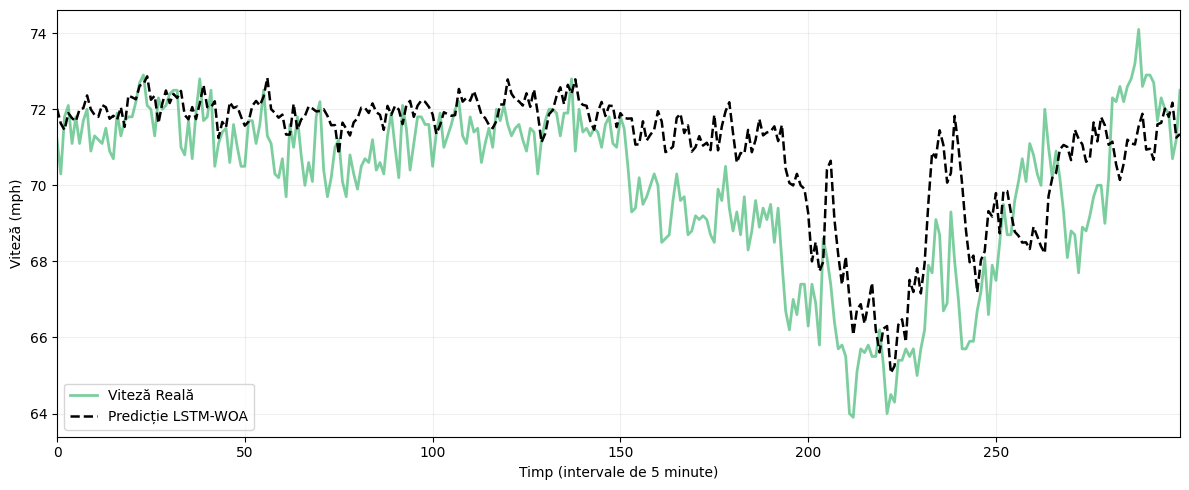

In [7]:
# Comparația dintre valorile reale și predicții
def prepare_data(p_path, scaler):
    if not os.path.exists(p_path):
        return None
    data = np.load(p_path)
    if np.max(data) <= 1.5: 
        data = scaler.inverse_transform(data)
    return data
    
START, END = 0, 300 
SENZOR_ID = 0  
if not os.path.exists("Rezultate"): 
    os.makedirs("Rezultate")

y_true_real = scaler_y.inverse_transform(y_test_s)
p_lstm_woa = prepare_data(os.path.join("Rezultate", "preds_V19_WOA.npy"), scaler_y)

plt.figure(figsize=(12, 5), facecolor='white')

plt.plot(
    y_true_real[START:END, SENZOR_ID],
    label="Viteză Reală",
    color='#27ae60',
    alpha=0.6,
    linewidth=2
)

if p_lstm_woa is not None:
    plt.plot(
        p_lstm_woa[START:END, SENZOR_ID],
        '--',
        label="Predicție LSTM-WOA",
        color='black',
        linewidth=1.8
    )


plt.ylabel("Viteză (mph)")
plt.xlabel("Timp (intervale de 5 minute)")
plt.legend(loc='lower left')
plt.grid(True, alpha=0.2)
plt.xlim(0, END - START - 1)
plt.tight_layout()
plt.savefig(os.path.join("Rezultate", "Predictie_C_LSTM_WOA.png"), dpi=300)
plt.show()

Worst Sensor ID: 29 | MAE: 6.2765
Best Sensor ID: 148 | MAE: 0.3470


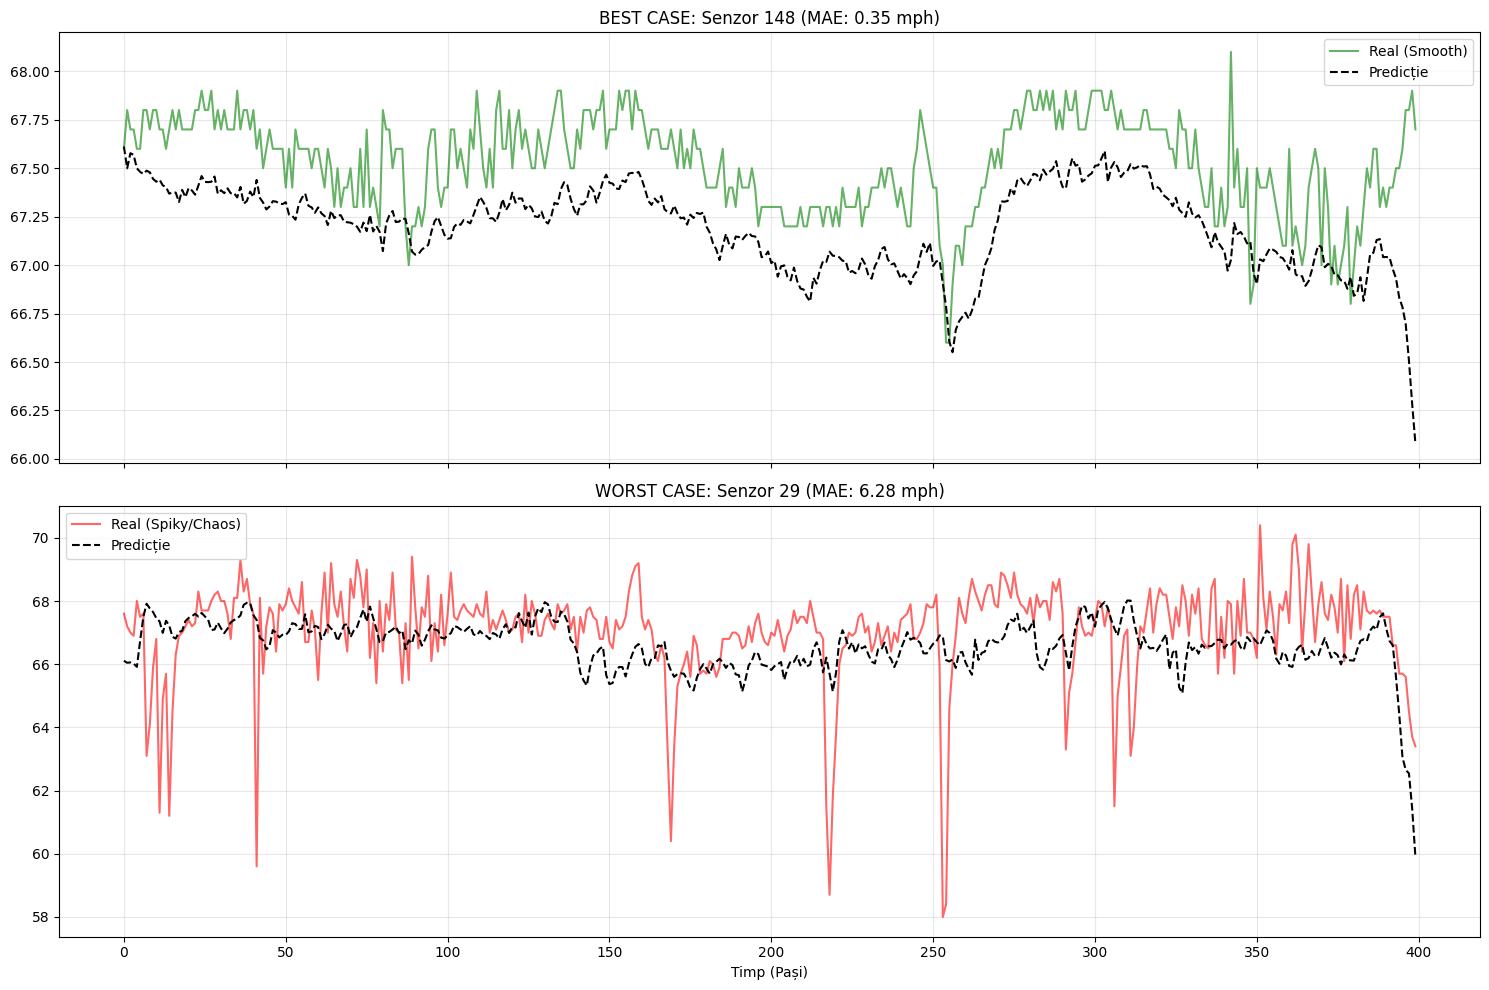

In [18]:
# Identificarea senzorilor cu cea mai bună și cea mai slabă performanță
mae_per_sensor = np.mean(np.abs(y_real - y_pred), axis=0)
worst_sensor_idx = np.argmax(mae_per_sensor)
worst_mae_val = mae_per_sensor[worst_sensor_idx]
best_sensor_idx = np.argmin(mae_per_sensor)
best_mae_val = mae_per_sensor[best_sensor_idx]

print(f"Worst Sensor ID: {worst_sensor_idx} | MAE: {worst_mae_val:.4f}")
print(f"Best Sensor ID: {best_sensor_idx} | MAE: {best_mae_val:.4f}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

ax1.plot(y_real[:400, best_sensor_idx], label='Real (Smooth)', color='green', alpha=0.6)
ax1.plot(y_pred[:400, best_sensor_idx], '--', label='Predicție', color='black')
ax1.set_title(f"BEST CASE: Senzor {best_sensor_idx} (MAE: {best_mae_val:.2f} mph)")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(y_real[:400, worst_sensor_idx], label='Real (Spiky/Chaos)', color='red', alpha=0.6)
ax2.plot(y_pred[:400, worst_sensor_idx], '--', label='Predicție', color='black')
ax2.set_title(f"WORST CASE: Senzor {worst_sensor_idx} (MAE: {worst_mae_val:.2f} mph)")
ax2.set_xlabel("Timp (Pași)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()